# 🎬 MovieLens Data Analytics Project
**Dataset:** MovieLens_Advanced_Project_Dataset.xlsx  
**Columns:** userId, movieId, title, genres, rating

## Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2: Load the Dataset

In [4]:
# Load the Excel file — update the path if needed
df = pd.read_excel(r'C:\Users\sharm\Downloads\MovieLens_Advanced_Project_Dataset.xlsx')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (800, 5)

First 5 rows:


,userId,movieId,title,genres,rating
0,23,1,Frozen,Thriller,3.2
1,87,2,The Dark Knight,Romance,2.0
2,162,3,Avatar,Sci-Fi,2.7
3,156,4,Avengers,Adventure,1.4
4,157,5,Inception,Drama,1.5


## Step 3: Data Overview & Basic Info

In [5]:
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicate Rows ===')
print(f'Total duplicates: {df.duplicated().sum()}')

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   userId   800 non-null    int64  
 1   movieId  800 non-null    int64  
 2   title    800 non-null    str    
 3   genres   800 non-null    str    
 4   rating   800 non-null    float64
dtypes: float64(1), int64(2), str(2)
memory usage: 31.4 KB

=== Missing Values ===
userId     0
movieId    0
title      0
genres     0
rating     0
dtype: int64

=== Duplicate Rows ===
Total duplicates: 0


In [6]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,userId,movieId,rating
count,800.000000,800.0000,800.000000
mean,100.948750,400.5000,2.973125
std,58.046709,231.0844,1.173131
min,1.000000,1.0000,1.000000
25%,50.000000,200.7500,2.000000
50%,99.000000,400.5000,2.950000
75%,155.000000,600.2500,4.000000
max,200.000000,800.0000,5.000000


## Step 4: Data Cleaning

In [7]:
# Drop duplicates if any
df.drop_duplicates(inplace=True)

# Drop rows with missing values (if any)
df.dropna(inplace=True)

# Strip whitespace from string columns
df['title'] = df['title'].str.strip()
df['genres'] = df['genres'].str.strip()

# Clip ratings to valid range 0.5 - 5.0
df['rating'] = df['rating'].clip(0.5, 5.0)

# Add a rating category column
df['rating_category'] = pd.cut(
    df['rating'],
    bins=[0, 2, 3, 4, 5],
    labels=['Poor (0-2)', 'Average (2-3)', 'Good (3-4)', 'Excellent (4-5)']
)

print(f'✅ Clean dataset shape: {df.shape}')
df.head()

✅ Clean dataset shape: (800, 6)


,userId,movieId,title,genres,rating,rating_category
0,23,1,Frozen,Thriller,3.2,Good (3-4)
1,87,2,The Dark Knight,Romance,2.0,Poor (0-2)
2,162,3,Avatar,Sci-Fi,2.7,Average (2-3)
3,156,4,Avengers,Adventure,1.4,Poor (0-2)
4,157,5,Inception,Drama,1.5,Poor (0-2)


## Step 5: Exploratory Data Analysis (EDA)

### 5.1 Rating Distribution

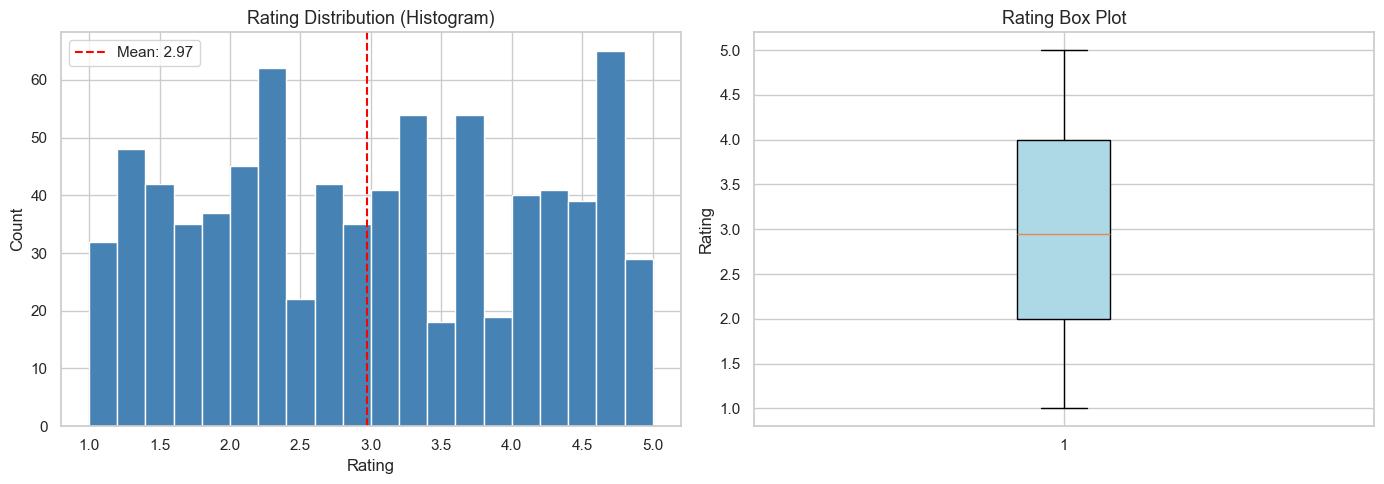

Mean Rating:   2.97
Median Rating: 2.95
Std Dev:       1.17


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['rating'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution (Histogram)', fontsize=13)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].axvline(df['rating'].mean(), color='red', linestyle='--', label=f'Mean: {df["rating"].mean():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['rating'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Rating Box Plot', fontsize=13)
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Mean Rating:   {df["rating"].mean():.2f}')
print(f'Median Rating: {df["rating"].median():.2f}')
print(f'Std Dev:       {df["rating"].std():.2f}')

### 5.2 Top 10 Highest Rated Movies

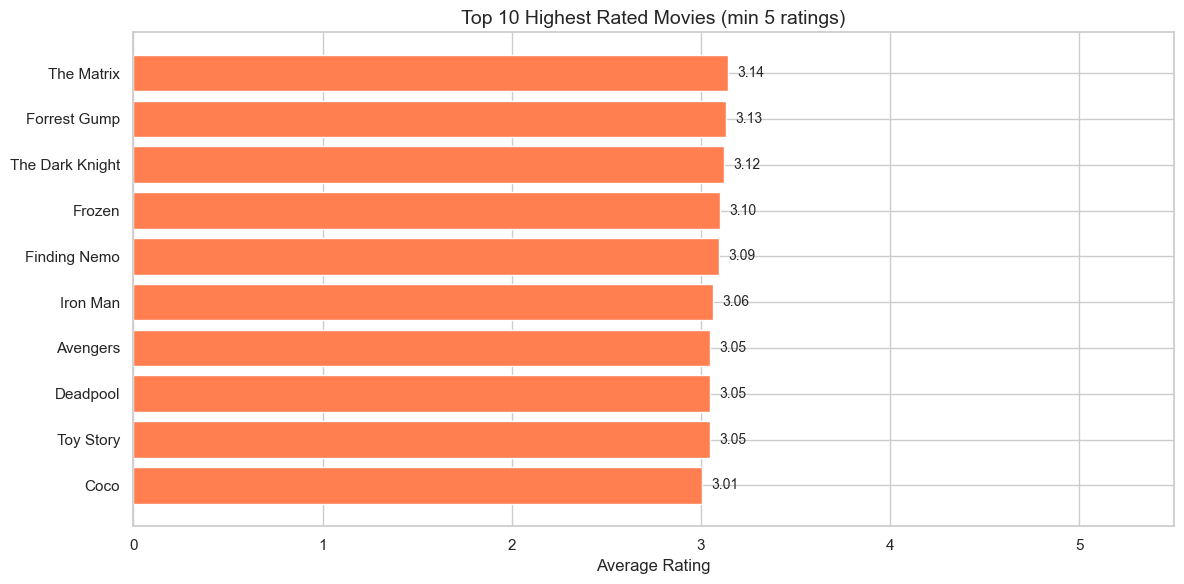

             title  avg_rating  num_ratings
0       The Matrix    3.140625           32
1     Forrest Gump    3.130556           36
2  The Dark Knight    3.120455           44
3           Frozen    3.102632           38
4     Finding Nemo    3.092857           42
5         Iron Man    3.061905           42
6         Avengers    3.047619           42
7         Deadpool    3.046341           41
8        Toy Story    3.045946           37
9             Coco    3.007317           41


In [11]:
top_movies = (
    df.groupby('title')['rating']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_rating', 'count': 'num_ratings'})
    .query('num_ratings >= 5')  # at least 5 ratings
    .sort_values('avg_rating', ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_movies['title'][::-1], top_movies['avg_rating'][::-1], color='coral', edgecolor='white')
plt.xlabel('Average Rating')
plt.title('Top 10 Highest Rated Movies (min 5 ratings)', fontsize=14)
plt.xlim(0, 5.5)
for bar, val in zip(bars, top_movies['avg_rating'][::-1]):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('top_movies.png', dpi=300, bbox_inches='tight')
plt.show()

print(top_movies)

### 5.3 Genre-wise Analysis

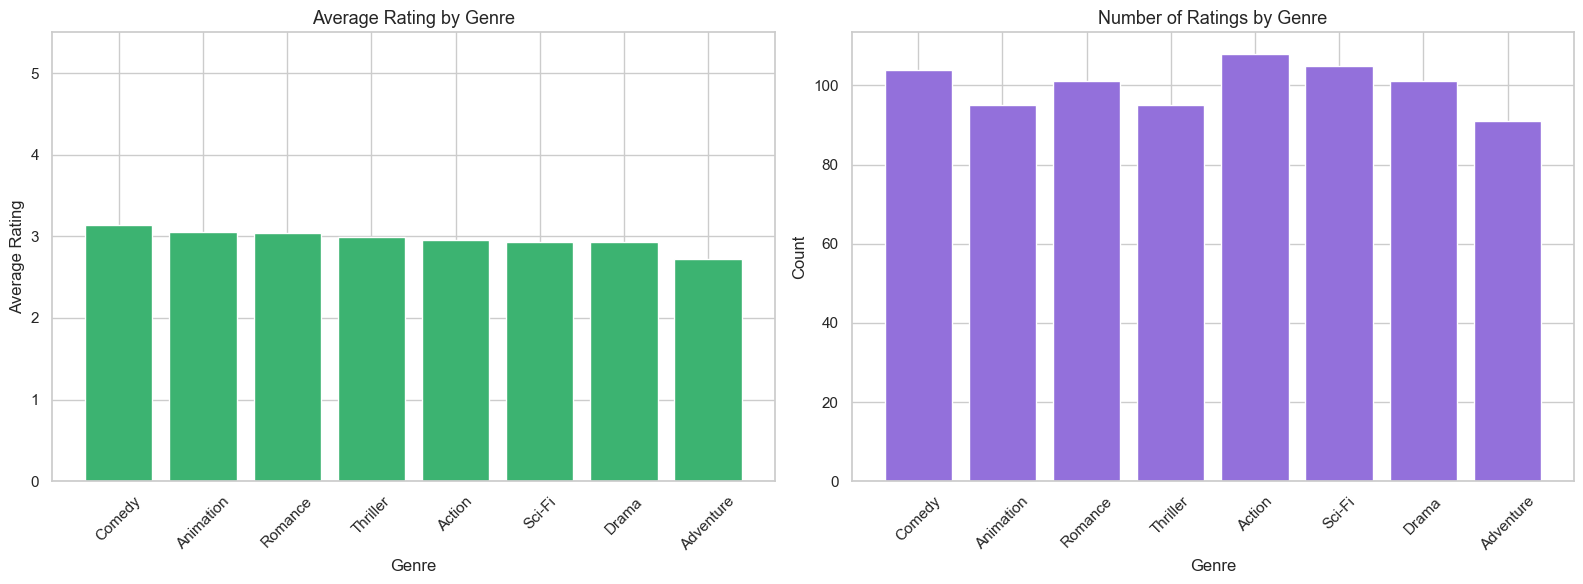

      genres  avg_rating  total_ratings
0     Comedy    3.139423            104
1  Animation    3.054737             95
2    Romance    3.043564            101
3   Thriller    2.987368             95
4     Action    2.958333            108
5     Sci-Fi    2.928571            105
6      Drama    2.927723            101
7  Adventure    2.724176             91


In [12]:
genre_stats = (
    df.groupby('genres')['rating']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_rating', 'count': 'total_ratings'})
    .sort_values('avg_rating', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avg rating by genre
axes[0].bar(genre_stats['genres'], genre_stats['avg_rating'], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Average Rating by Genre', fontsize=13)
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Average Rating')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 5.5)

# Count of ratings by genre
axes[1].bar(genre_stats['genres'], genre_stats['total_ratings'], color='mediumpurple', edgecolor='white')
axes[1].set_title('Number of Ratings by Genre', fontsize=13)
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('genre_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(genre_stats)

### 5.4 Rating Category Breakdown

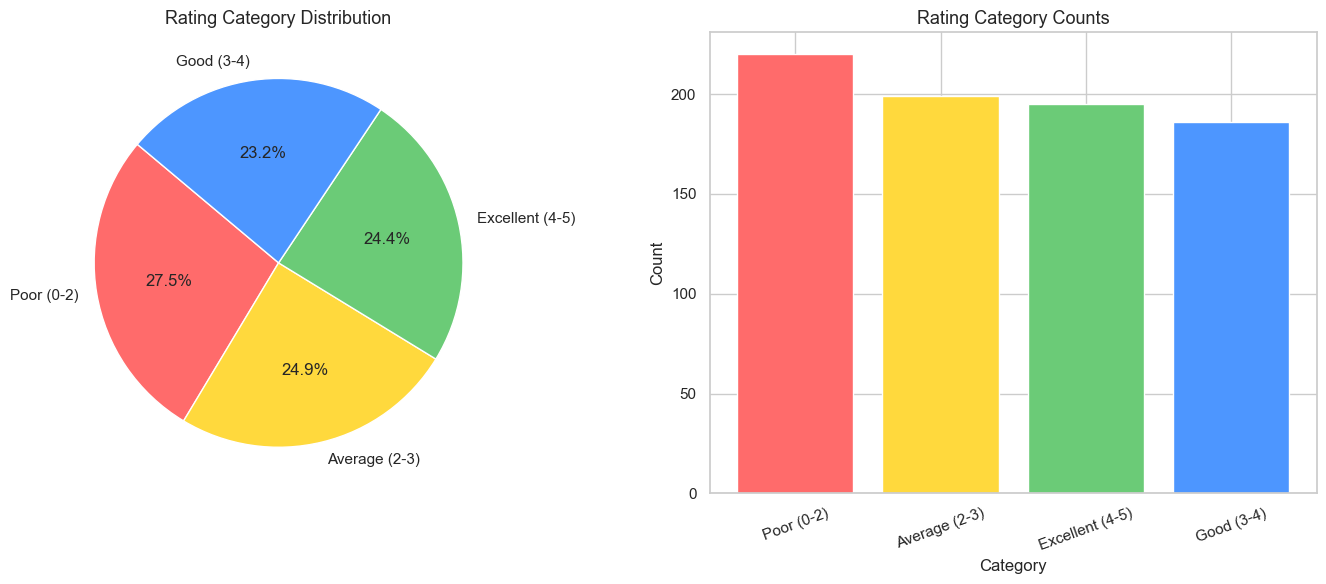

In [13]:
cat_counts = df['rating_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=['#ff6b6b','#ffd93d','#6bcb77','#4d96ff'], startangle=140)
axes[0].set_title('Rating Category Distribution', fontsize=13)

# Bar chart
axes[1].bar(cat_counts.index, cat_counts.values,
            color=['#ff6b6b','#ffd93d','#6bcb77','#4d96ff'], edgecolor='white')
axes[1].set_title('Rating Category Counts', fontsize=13)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('rating_categories.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.5 Most Active Users (Top 10)

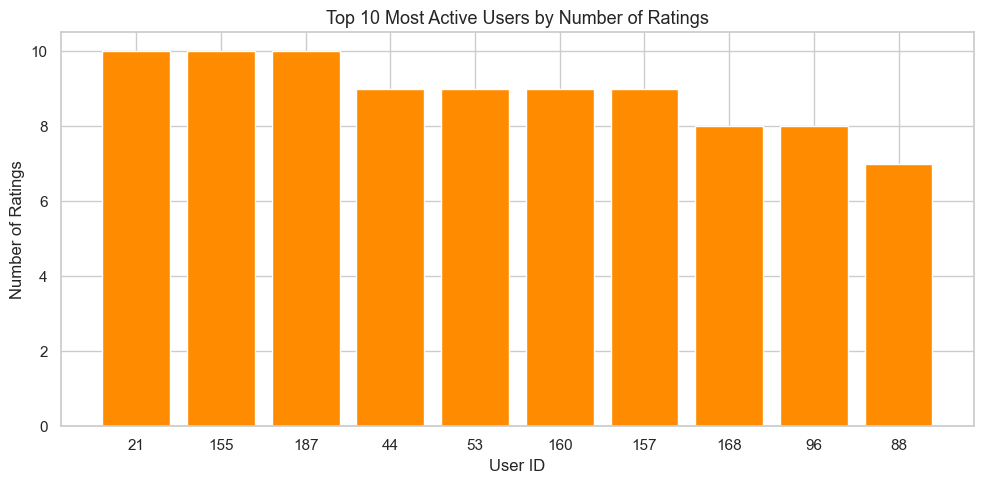

   userId  num_ratings
0      21           10
1     155           10
2     187           10
3      44            9
4      53            9
5     160            9
6     157            9
7     168            8
8      96            8
9      88            7


In [14]:
top_users = df.groupby('userId')['rating'].count().sort_values(ascending=False).head(10).reset_index()
top_users.columns = ['userId', 'num_ratings']

plt.figure(figsize=(10, 5))
plt.bar(top_users['userId'].astype(str), top_users['num_ratings'], color='darkorange', edgecolor='white')
plt.title('Top 10 Most Active Users by Number of Ratings', fontsize=13)
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.savefig('top_users.png', dpi=300, bbox_inches='tight')
plt.show()

print(top_users)

### 5.6 Heatmap: Avg Rating per Movie per Genre

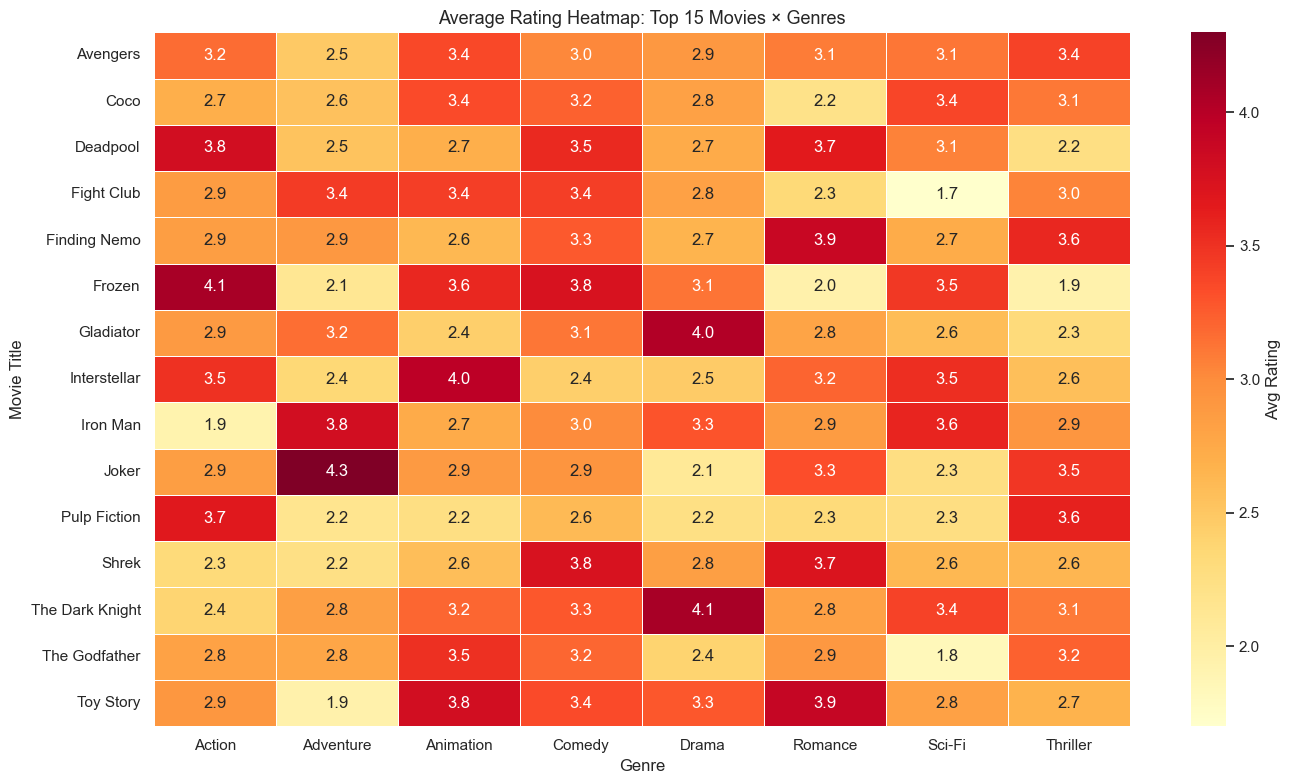

In [15]:
# Pivot table: movies vs genres
pivot = df.pivot_table(values='rating', index='title', columns='genres', aggfunc='mean')

# Select top 15 movies by total ratings for a cleaner heatmap
top15 = df['title'].value_counts().head(15).index
pivot_top = pivot.loc[pivot.index.isin(top15)]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_top, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Avg Rating'})
plt.title('Average Rating Heatmap: Top 15 Movies × Genres', fontsize=13)
plt.xlabel('Genre')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 6: Key Insights Summary

In [16]:
print('=' * 50)
print('          📊 KEY INSIGHTS SUMMARY')
print('=' * 50)
print(f"Total Ratings       : {len(df)}")
print(f"Unique Users        : {df['userId'].nunique()}")
print(f"Unique Movies       : {df['title'].nunique()}")
print(f"Unique Genres       : {df['genres'].nunique()}")
print(f"Overall Avg Rating  : {df['rating'].mean():.2f}")
print(f"Highest Rated Movie : {df.groupby('title')['rating'].mean().idxmax()}")
print(f"Most Reviewed Movie : {df['title'].value_counts().idxmax()} ({df['title'].value_counts().max()} ratings)")
print(f"Best Genre (avg)    : {df.groupby('genres')['rating'].mean().idxmax()}")
print(f"Most Active User ID : {df['userId'].value_counts().idxmax()}")
print('=' * 50)

          📊 KEY INSIGHTS SUMMARY
Total Ratings       : 800
Unique Users        : 197
Unique Movies       : 20
Unique Genres       : 8
Overall Avg Rating  : 2.97
Highest Rated Movie : The Matrix
Most Reviewed Movie : Gladiator (53 ratings)
Best Genre (avg)    : Comedy
Most Active User ID : 187
